In [1]:
!pip install keras-tuner

In [1]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from kerastuner.tuners import BayesianOptimization
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

C:\Users\Tej Bahadur\AppData\Local\Temp\ipykernel_12788\2752237541.py:6: DeprecationWarning: `import kerastuner` is deprecated, please use `import keras_tuner`.
  from kerastuner.tuners import BayesianOptimization


In [3]:

train_dataset = 'brain-tumor-mri-dataset\Training'  
val_dataset = 'brain-tumor-mri-dataset\Testing'

train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dataset,  
    target_size=(224, 224),
    batch_size=32,
    class_mode='sparse'
)

val_generator = val_datagen.flow_from_directory(
    val_dataset,  
    target_size=(224, 224),
    batch_size=32,
    class_mode='sparse'
)

Found 5712 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.


In [4]:

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights_dict = dict(enumerate(class_weights))


In [5]:
# Define the model-building function for VGG16 with tunable parameters
def build_model(hp):
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

    # Freeze the base model layers (optional, can be tuned)
    base_model.trainable = hp.Boolean('trainable_base', default=False)

    # Add custom top layers
    x = base_model.output
    x = Flatten()(x)

    # Tune the number of neurons in the dense layer
    x = Dense(units=hp.Int('units', min_value=64, max_value=512, step=64), activation='relu')(x)

    # Tune the dropout rate
    x = Dropout(rate=hp.Float('dropout', min_value=0.2, max_value=0.5, step=0.1))(x)

    # Final output layer for the 4 classes
    output = Dense(4, activation='softmax')(x)

    # Create the model
    model = Model(inputs=base_model.input, outputs=output)

    # Tune the optimizer
    optimizer = hp.Choice('optimizer', ['adam', 'rmsprop', 'sgd'])

    if optimizer == 'adam':
        optimizer = Adam(hp.Float('learning_rate', min_value=1e-5, max_value=1e-3, sampling='LOG'))
    elif optimizer == 'rmsprop':
        optimizer = RMSprop(hp.Float('learning_rate', min_value=1e-5, max_value=1e-3, sampling='LOG'))
    else:
        optimizer = SGD(hp.Float('learning_rate', min_value=1e-5, max_value=1e-3, sampling='LOG'))

    # Compile the model
    model.compile(optimizer=optimizer,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    return model

In [6]:

tuner = BayesianOptimization(
    build_model,
    objective='val_accuracy',
    max_trials=20,
    directory='brain_tumor_vgg16_tuning',
    project_name='vgg16_bayes_opt'
)

tuner.search(train_generator, validation_data=val_generator, epochs=10, class_weight=class_weights_dict)

best_model = tuner.get_best_models(num_models=1)[0]

Reloading Tuner from brain_tumor_vgg16_tuning\vgg16_bayes_opt\tuner0.json



c:\Users\Tej Bahadur\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:415: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 32 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [12]:
best_hyperparameters = tuner.get_best_hyperparameters(num_trials=1)[0]

# Print the best parameters
print(best_hyperparameters.values)

{'trainable_base': True, 'units': 64, 'dropout': 0.2, 'optimizer': 'rmsprop', 'learning_rate': 6.802324244182384e-05}


In [8]:
history = best_model.fit(train_generator, validation_data=val_generator, epochs=10, class_weight=class_weights_dict)

Epoch 1/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 525s 3s/step - accuracy: 0.9442 - loss: 0.2777 - val_accuracy: 0.9672 - val_loss: 0.1151
Epoch 2/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 526s 3s/step - accuracy: 0.9611 - loss: 0.1438 - val_accuracy: 0.9748 - val_loss: 0.1341
Epoch 3/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 513s 3s/step - accuracy: 0.9557 - loss: 0.1494 - val_accuracy: 0.9886 - val_loss: 0.0466
Epoch 4/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 504s 3s/step - accuracy: 0.9664 - loss: 0.1437 - val_accuracy: 0.9863 - val_loss: 0.0404
Epoch 5/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 497s 3s/step - accuracy: 0.9655 - loss: 0.1069 - val_accuracy: 0.9893 - val_loss: 0.0392
Epoch 6/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 504s 3s/step - accuracy: 0.9685 - loss: 0.0991 - val_accuracy: 0.9825 - val_loss: 0.0622
Epoch 7/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 500s 3s/step - accuracy: 0.9723 - loss: 0.1023 - val_accuracy: 0.9809 - val_loss: 0.0707
Epoch 8/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 498s 3s/step - accuracy: 0.9691 - loss: 0.0979 - val_accu

In [12]:
test_loss, test_accuracy = best_model.evaluate(val_generator)
print(f'Test Loss: {test_loss*100}')
print(f'Test Accuracy: {test_accuracy*100}')

41/41 ━━━━━━━━━━━━━━━━━━━━ 31s 764ms/step - accuracy: 0.9883 - loss: 0.0658
Test Loss: 7.011111080646515
Test Accuracy: 99.00839328765869


In [20]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(val_generator.classes),
    y=val_generator.classes
)

class_weights_dict = dict(enumerate(class_weights))


In [21]:
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
)

# Get predictions for the validation data
val_steps = val_generator.samples // val_generator.batch_size
y_true = []
y_pred = []
y_proba = []  # For AUC

for i in range(val_steps):
    X_batch, y_batch = next(val_generator)
    predictions = best_model.predict(X_batch)
    
    # Convert probabilities to class labels
    y_pred_batch = np.argmax(predictions, axis=1)
    y_true_batch = np.argmax(y_batch, axis=1) if len(y_batch.shape) == 2 else y_batch
    
    y_true.extend(y_true_batch)
    y_pred.extend(y_pred_batch)
    y_proba.extend(predictions)  # Save probabilities for AUC

# Convert lists to numpy arrays for metric calculations
y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_proba = np.array(y_proba)

# Calculate metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

# Calculate AUC
# You need to consider only the probabilities of the positive class for binary classification
# For multiclass, you can use the "macro" or "weighted" option depending on your needs
# Here's an example for multiclass AUC (one-vs-rest approach)
if len(np.unique(y_true)) > 2:  # More than 2 classes
    auc = roc_auc_score(y_true, y_proba, multi_class='ovr', average='weighted')
else:
    auc = roc_auc_score(y_true, y_proba[:, 1])  # For binary case

# Print metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC: {auc:.4f}")

# Optional: Detailed classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=val_generator.class_indices.keys()))


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 771ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 773ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 766ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 796ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 788ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 766ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 771ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 803ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 784ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 782ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 773ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 765ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 769ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 796ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 774ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 764ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 785ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 784ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 798ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 831ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 776ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 796ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 824ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 803ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 826ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

In [24]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(val_generator.classes),
    y=val_generator.classes
)

class_weights_dict = dict(enumerate(class_weights))


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 757ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 798ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 756ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 794ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 759ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 785ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 796ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 768ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 833ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 770ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 764ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 763ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 801ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 832ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 747ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 770ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 749ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 756ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 768ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 744ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 759ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 805ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 767ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 759ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 761ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

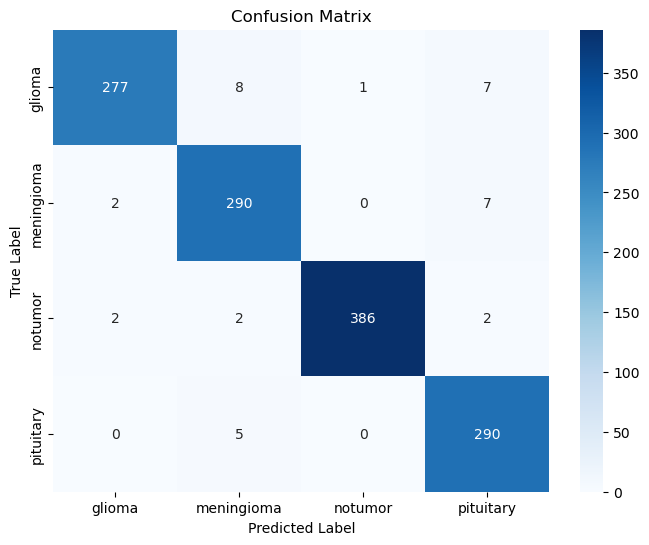

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Get predictions for the validation data
val_steps = val_generator.samples // val_generator.batch_size
y_true = []
y_pred = []

for i in range(val_steps):
    X_batch, y_batch = next(val_generator)
    predictions = best_model.predict(X_batch)
    
    # Convert probabilities to class labels
    y_pred_batch = np.argmax(predictions, axis=1)
    y_true_batch = np.argmax(y_batch, axis=1) if len(y_batch.shape) == 2 else y_batch
    
    y_true.extend(y_true_batch)
    y_pred.extend(y_pred_batch)

# Convert lists to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=val_generator.class_indices.keys(), yticklabels=val_generator.class_indices.keys())
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


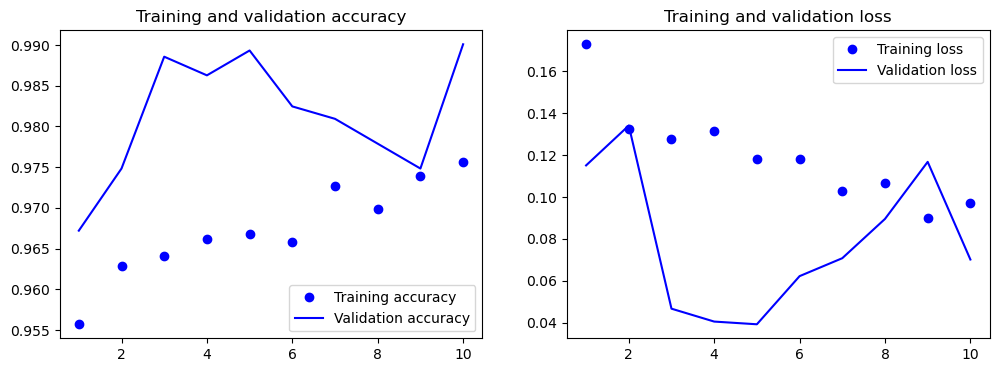

In [11]:
# Plot the training history
def plot_training_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    
    epochs = range(1, len(acc) + 1)
    
    # Plot accuracy
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'bo', label='Training accuracy')
    plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
    plt.title('Training and validation accuracy')
    plt.legend()
    
    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'bo', label='Training loss')
    plt.plot(epochs, val_loss, 'b', label='Validation loss')
    plt.title('Training and validation loss')
    plt.legend()
    
    plt.show()

# Plot the training metrics
plot_training_history(history)


In [15]:
best_model.save('resnet50-brain-tumor.h5')